In [1]:
from preamble import *

2025-02-19 13:02:20,048 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch


  0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
def ramp_model(phase, r1, r2, r3):
    
    ramp = 1. - np.exp( (-r1 * phase) + r2) + (r3 * phase)

    return ramp

# Define the log probability

In [4]:
def lnprob(parameters, plot=False, plot_label=None,**kwargs):
    """
    Log-probability function for MCMC.

    Parameters:
    - parameters: np.ndarray, current parameter values.
    - kwargs: dict, additional arguments required for model computation.

    Returns:
    - ln_like: float, log-likelihood of the current parameter set.
    """
    ln_like = 0.0

    # Map parameters to names for easier reference
    params = {name: value for name, value in zip(params_config.keys(), parameters)}

    'Check if all priors are satisfied'
    if all(bounds[0] <= params[key] <= bounds[1] for key, bounds in priors.items()):

        'Set binning preferences and download model spectra'
        kwargs = dict(
        bin_specification = 'edges',
        bins=bin_edges,
        min=bin_edges.min(),
        max=bin_edges.max(), log=False)
        Cool, Phot = [
            bin_spectrum(
                get_spectrum(T_eff=Temp, log_g=log_g, Z=0.12, cache=True), **kwargs
            )
            for Temp in [params.get('T_spot', default_params['T_spot']), params.get('T_phot', default_params['T_phot'])] ]

        'Update Planet Parameters'
        planet_parameters['a'] = params.get('a_rstar', default_params['a_rstar'])
        planet_parameters['ecc'] = params.get('ecc', default_params['ecc'])
        planet_parameters['inclination'] = np.radians(params.get('planet_i', default_params['planet_i']))
        planet_parameters['u1'] = params.get('u1', default_params['u1'])
        planet_parameters['u2'] = params.get('u2', default_params['u2'])
        planet_parameters['rp'] = ((params.get('R_0', default_params['R_0']) * u.R_earth) / Rs).decompose()

        if visit == 'F21':
            planet_parameters['t0'] = 0
            lc_index=1
        if visit == 'S22':
            planet_parameters['t0'] = params.get('T_0', default_params['T_0'])
            lc_index=0
        
        # Update stellar parameters
        active_star.T_eff = Phot.meta['PHXTEFF']
        active_star.phot = Phot.flux.value
        active_star.wavelength = Phot.wavelength.to_value(u.m)
        active_star.temperature = jnp.array([Cool.meta['PHXTEFF']] * n_spots)
        active_star.spectrum = jnp.array([Cool.flux.value] * n_spots)
        active_star.lon = jnp.array([params.get(f"spot{i}_lon", default_params[f"spot{i}_lon"]) for i in range(1, n_spots + 1)])
        active_star.lat = jnp.array([params.get(f"spot{i}_lat", default_params[f"spot{i}_lat"]) for i in range(1, n_spots + 1)])
        active_star.rad = jnp.array([params.get(f"spot{i}_rad", default_params[f"spot{i}_rad"]) for i in range(1, n_spots + 1)])
        
        if plot:
            'Plot the stellar surface'
            active_star.plot_star(
                t0=0,
                rp=(params.get('R_0', default_params['R_0']) * u.R_earth / Rs).decompose(),  # Exoplanet radius in units of stellar radii
                a=params.get('a_rstar', default_params['a_rstar']),  # Planetary semi-major axis in units of stellar radii
                inclination=np.radians(params.get('planet_i', default_params['planet_i'])),  # Planetary orbital inclination [radians]
                ecc=params.get('ecc', default_params['ecc'])  # Planetary eccentricity
            )
            plt.title(f'Stellar Background at T0')
            plt.savefig(f'../figs/{visit}_{n_spots}spots_{nsteps}steps_starmap.png', dpi=300)
            plt.show()
            plt.clf()
        
            'Set up the data + model plots'
            fig, axes = plt.subplots(4, 1, figsize=(6, 10))
            axes[0].set_title(f"{visit}")
            axes[0].set_xlabel("Time from midtransit")
            axes[0].set_ylabel("Relative Flux")
            axes[1].set_title("Systematic-corrected")
            axes[1].set_xlabel("Time from midtransit")
            axes[2].set_title("Residuals")
            axes[2].set_xlabel("Time from midtransit")
            axes[2].set_ylabel(r"$\sigma$")
            axes[3].set_title("Residuals")
            axes[3].set_xlabel("HST Phase")
            axes[3].set_ylabel(r"$\sigma$")
            
            total_chisq = 0
            for data_flux, relative_err, img_date, time_from_T0, direction, ramp_phase in zip(data_fluxes, relative_errs, img_dates, times_from_T0, ['Forward', 'Backward'], ramp_phases):
                
                active_star.times = time_from_T0
                lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)
            
                ramp = ramp_model(phase = ramp_phase,
                                  r1=params.get('r1', default_params['r1']),
                                  r2=params.get('r2', default_params['r2']),
                                  r3=params.get('r3', default_params['r3']),
                                  )
                bphase = (img_date-ref_time[0]) % hst_per_in_days
                # breathing = breathing_model(phase = bphase,
                #                             b1=params.get('b1', default_params['b1']),
                #                             b2=params.get('b2', default_params['b2']),
                #                             b3=params.get('b3', default_params['b3']),
                #                             b4=params.get('b4', default_params['b4']),
                #                            )
                # systematics = ramp*breathing
                systematics = ramp
            
            
                fleck_lc = lc.T[lc_index]
                fleck_lc /= np.nanmean(fleck_lc)
                model = systematics * fleck_lc
                normalized_model = model / np.nanmean(model)
                normalized_flux = data_flux / np.nanmean(data_flux)
                chisq = np.nansum(((normalized_flux - normalized_model) ** 2) / (relative_err ** 2))
                total_chisq+=chisq
                
                # First plot (data + model)
                axes[0].errorbar(
                    time_from_T0,
                    normalized_flux,
                    yerr=relative_err,label=f'{direction}',fmt='o',ms=2,alpha=0.9)
                # Second plot (data & model)/systematics
                axes[1].errorbar(
                    time_from_T0,
                    (normalized_flux/systematics)/np.nanmean(normalized_flux/systematics),
                    yerr=relative_err,label=f'{direction}',fmt='o',ms=2,alpha=0.9)
                # third plot (data & model)/systematics
                axes[2].scatter(
                    time_from_T0,
                    (normalized_flux-normalized_model)/relative_err,s=1.5,alpha=0.8)
                
                if direction =='Forward':
                    axes[0].plot(
                        time_from_T0,
                        normalized_model,alpha=0.8,
                        color='k',zorder=100,label='Spotted Transit + Systematics')
                    axes[1].plot(
                        time_from_T0,
                        fleck_lc,alpha=0.8,
                        color='k',zorder=100,label='Spotted Transit')
                    
            axes[0].legend(loc='upper right',fontsize=10)
            axes[1].legend(loc='upper right',fontsize=10)
            plt.savefig(f'../figs/{visit}_lightcurvemodels.png')
            plt.show()

            reduced_chisq = total_chisq/( 2*np.sum(~np.isnan(time_from_T0)) - ndim)
            print(f'This Models Reduced Chisq = {reduced_chisq} for {ndim} parameters and {2*np.sum(~np.isnan(time_from_T0))} data points')

            fig, axes = plt.subplots(3, 1, figsize=(6, 6),sharex=True)
            axes[0].set_title(f"{visit}")
            axes[0].set_ylabel("Relative Flux")
            axes[1].set_title("Systematic-corrected")
            axes[1].set_ylabel("Relative Flux")
            # axes[2].set_title("Rotation-corrected")
            # axes[2].set_ylabel("Relative Flux") 
            # axes[2].set_title("Residuals")
            axes[2].set_xlabel("Time from midtransit")
            axes[2].set_ylabel(r"$\sigma$")
            # axes[0].set_ylim(0.9955,1.0045)
            # axes[1].set_ylim(0.9955,1.0045)
            # axes[2].set_ylim(0.9955,1.002)
            
            for data_flux, relative_err, img_date, time_from_T0, direction, ramp_phase in zip(data_fluxes, relative_errs, img_dates, times_from_T0, ['Forward', 'Backward'], ramp_phases):
                active_star.times = time_from_T0
                lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)

                bphase = (img_date-ref_time[0]+params.get('phase_offset', default_params['phase_offset'])) % hst_per_in_days
                ramp = ramp_model(phase=ramp_phase,
                                  r1=params.get('r1', default_params['r1']),
                                  r2=params.get('r2', default_params['r2']),
                                  r3=params.get('r3', default_params['r3']),
                                 )
                breathing = breathing_model(phase=bphase,
                                            b1=params.get('b1', default_params['b1']),
                                            b2=params.get('b2', default_params['b2']),
                                            b3=params.get('b3', default_params['b3']),
                                            b4=params.get('b4', default_params['b4']),
                                            )
                systematics = ramp*breathing
            
                fleck_lc = lc.T[lc_index]
                fleck_lc /= np.nanmean(fleck_lc)
                model = systematics * fleck_lc
                normalized_model = model / np.nanmean(model)
                normalized_flux = data_flux / np.nanmean(data_flux)

                # rot = active_star.rotation_spectrum()
                # rotation = rot.T[lc_index]
                # rotation/=np.nanmean(rotation)
                
                # First plot (data + model)
                axes[0].errorbar(
                    time_from_T0,
                    normalized_flux,
                    yerr=relative_err,label=f'{direction}',fmt='o',ms=2,alpha=0.9)
                # Second plot (data & model)/systematics
                axes[1].errorbar(
                    time_from_T0,
                    (normalized_flux/systematics)/np.nanmean(normalized_flux/systematics),
                    yerr=relative_err,label=f'{direction}',fmt='o',ms=2,alpha=0.9)
                # axes[2].errorbar(
                #     time_from_T0,
                #     normalized_flux/(systematics*rotation)/np.nanmean(normalized_flux/(systematics*rotation)),
                #     yerr=relative_err,label=f'{direction}',fmt='o',ms=1,alpha=0.9)
                # third plot (data & model)/systematics
                axes[2].scatter(
                    time_from_T0,
                    (normalized_flux-normalized_model)/relative_err, s=2,alpha=0.8)
                
                if direction =='Forward':
                    axes[0].plot(
                        time_from_T0,
                        normalized_model,alpha=0.8,label='fleck x ramp',
                        color='k',zorder=100)
                    axes[1].plot(
                        time_from_T0,
                        fleck_lc,alpha=0.8,
                        color='k',zorder=100,label='fleck (transit and rotation)')
                    # axes[2].plot(
                    #     time_from_T0,
                    #     (fleck_lc/rotation_curve)/np.nanmean(fleck_lc/rotation_curve),alpha=0.8,
                    #     color='k',zorder=100,label='transit/rotation')
                    
            plt.xlim(-0.1,0.1)
            axes[0].legend(loc='upper right',fontsize=10)
            axes[1].legend(loc='upper right',fontsize=10)
            plt.savefig(f'../figs/{visit}_lightcurvemodels_zoomedin.png',dpi=300)
            plt.show()
            
        for data_flux, relative_err, img_date, time_from_T0, direction, ramp_phase in zip(data_fluxes, relative_errs, img_dates, times_from_T0, ['Forward', 'Backward'], ramp_phases):
            active_star.times = time_from_T0
            
            lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)
            
            bphase = (img_date-ref_time[0]+params.get('phase_offset', default_params['phase_offset'])) % hst_per_in_days
            ramp = ramp_model(phase=ramp_phase,
                              r1=params.get('r1', default_params['r1']),
                              r2=params.get('r2', default_params['r2']),
                              r3=params.get('r3', default_params['r3']),
                             )
            breathing = breathing_model(phase=bphase,
                                        b1=params.get('b1', default_params['b1']),
                                        b2=params.get('b2', default_params['b2']),
                                        b3=params.get('b3', default_params['b3']),
                                        b4=params.get('b4', default_params['b4']),
                                        )
            systematics = ramp*breathing
            
            fleck_lc = lc.T[lc_index]
        
            fleck_lc /= np.nanmean(fleck_lc)
            model = systematics * fleck_lc
            normalized_model = model / np.nanmean(model)
            normalized_flux = data_flux / np.nanmean(data_flux)
            chisq = np.nansum(((normalized_flux - normalized_model) ** 2) / (relative_err ** 2))
            err_weight = np.nansum(1.0 / np.sqrt(2.0 * np.pi * (relative_err)))
        
            ln_like += (err_weight - 0.5 * chisq)      

        return ln_like

    else:
        return -np.inf

## Set up MCMC

In [55]:
F21_default_params={
    # Ramp Model Parameters
    "r1": 9,
    "r2":-6.39873207e+00,
    "r3":3.59989871e-04,
    #Breathing params
    # "b1":-8.58554693e-02,
    # "b2":1.59614299e+00,
    # "b3":-6.69712540e+00,
    # "b4":9.94369942e+01,
    # "phase_offset":2.34544174e-02,
    # Transit Parameters
    "T_0":0.0,
    "u1": 2.24026301e-01,#0.215,
    "u2": 3.61541444e-01,#0.37,
    "R_0": 3.67754833e+00,#3.67,
    "a_rstar": 1.84869028e+01,#18.57,
    "ecc": 3.56870453e-02,#0.031,
    'planet_i': 89.5, # Range from 85 to 90 deg, or 1.47-1.57radians
    # Stellar Parameters
    "stellar_i":85.0,
    "T_spot": 3100,
    "T_phot": 4000,
    "spot1_lon":-1.20502633e+00,
    "spot1_lat":8.19568099e-01,
    "spot1_rad":5.43134600e-01,
    "spot2_lon":1.25751751e+00,
    "spot2_lat":2.43227973e+00,
    "spot2_rad":5.55496881e-01,
    "spot3_lon":4.19901970e-02,
    "spot3_lat":1.50050631e+00,
    "spot3_rad":3.12392054e-01,
    "spot4_lon":0,
    "spot4_lat":0,
    "spot4_rad":0
}

S22_default_params={
    # Ramp Model Parameters
    "r1": 8.15033566,
    "r2": -5.9,
    "r3": -7e-04,
    #Breathing params
    # "b1":-9.36463714e-02,
    # "b2":1.17939833e+00,
    # "b3":5.57611351e+00,
    # "b4":-2.54541811e+00,
    # "phase_offset":0.02, #-1.47750769e-02
    # Transit Parameters
    "T_0":0.0,
    "u1": 2.68077234e-01,
    "u2": 3.67120743e-01,
    "R_0": 3.70224111e+00,
    "a_rstar": 1.81965974e+01,
    "ecc": 5.18365421e-02,
    'planet_i': 89.5, # Range from 85 to 90 deg, or 1.47-1.57radians
    # Stellar Parameters
    "stellar_i":85.0,
    "T_spot": 3100,
    "T_phot": 4000,
    "spot1_lon": -1.22139912e+00,
    "spot1_lat": 9.97062041e-01,
    "spot1_rad": 5.80378385e-01,
    "spot2_lon": 1.14385752e+00,
    "spot2_lat": 2.43704748e+00,
    "spot2_rad": 5.99858332e-01,
    "spot3_lon": 5.79647195e-02,
    "spot3_lat": 1.50515507e+00,
    "spot3_rad": 2.94827793e-01,
    "spot4_lon": 8.74885497e-01,
    "spot4_lat": 1.84447583e+00,
    "spot4_rad": 6.80689502e-02
}

F21_params_config={
    # Ramp Model Parameters
    "r1": (1.0,20),
    "r2": (-7.0,-3.0),
    "r3": (-0.001,0.001),
    #Breathing params
    "b1":(-2,2),
    "b2":(-10, 10),
    "b3":(-50,50),
    "b4":(-250,150),
    "phase_offset":(0.0,0.02),
    # Transit Parameters
    "u1": (0.2,0.3),
    "u2": (0.3, 0.39),
    "R_0": (3.4,3.9),
    "a_rstar": (18.0,19),
    "ecc": (0.0,0.09),
    # 'planet_i': 89.5, # Range from 85 to 90 deg, or 1.47-1.57radians
    # Stellar Parameters
    # "stellar_i":(88.0,90.0),
    # "T_spot": (3000,3200),
    # "T_phot": (3900,4100),
    "spot1_lon": (-1.28,-1.1),
    "spot1_lat": (0.79,0.9),
    "spot1_rad": (0.55,0.57),
    "spot2_lon": (1.26,1.28),
    "spot2_lat": (2.42,2.44),
    "spot2_rad": (0.54,0.58),
    "spot3_lon": (0.01,0.1),
    "spot3_lat": (1.45,1.6),
    "spot3_rad": (0.3,0.4),
    "spot4_lon": (0.8,0.91),
    "spot4_lat": (1.77,1.81),
    "spot4_rad": (0.0,0.01)
}

S22_params_config={
    # Ramp Model Parameters
    "r1": (1,12), 
    "r2": (-10.0,-3.0),
    "r3": (-0.001,0.001),
    #Breathing params
    "b1":(-0.1,0),
    "b2":(-2.0, -1.0),
    "b3":(10,50),
    "b4":(-100,0),
    "phase_offset":(-0.02,0.02),
    # Transit Parameters
    "u1": (0.25,0.29),
    "u2": (0.36,0.395),
    "R_0": (3.55,3.75),
    "a_rstar": (18,18.5),
    "ecc": (0.03,0.07),
    # 'planet_i': 89.5, # Range from 85 to 90 deg, or 1.47-1.57radians
    # Stellar Parameters
    # "stellar_i":(87.4,88.2),
    # "T_spot": (3050,3150),
    # "T_phot": (3950,4150),
    "spot1_lon": (-1.2,-1.0),
    "spot1_lat": (0.9,1.1),
    "spot1_rad": (0.55,0.68),
    "spot2_lon": (1.1,1.28),
    "spot2_lat": (2.35,2.45),
    "spot2_rad": (0.57,0.6),
    "spot3_lon": (0.01,0.1),
    "spot3_lat": (1.47,1.52),
    "spot3_rad": (0.28,0.33),
    "spot4_lon": (0.87,0.89),
    "spot4_lat": (1.77,1.81),
    "spot4_rad": (0.04,0.08)
}

priors={
    # Ramp Model Parameters
    "r1": (0,20.0),
    "r2": (-10,0),
    "r3": (-0.01,0.01),
    #Breathing params
    "b1":(-10,10),
    "b2":(-50,50),
    "b3":(-200,200),
    "b4":(-300,300),
    "phase_offset":(-0.05,0.05),
    # Transit Parameters
    "u1": (0.2,0.3),
    "u2": (0.2,0.4),
    "R_0": (3.4,3.9),
    "a_rstar": (17.5,19.5),
    "ecc": (0.01,0.15),
    # 'planet_i': 89.5, # Range from 85 to 90 deg, or 1.47-1.57radians
    # Stellar Parameters
    # "stellar_i":(80.0,90.0),
    # "T_spot": (2800,3300),
    # "T_phot": (3900,4200),
    "spot1_lon": (-1.9,-0.8),
    "spot1_lat": (0.7,1.9),
    "spot1_rad": (0.3,0.8),
    "spot2_lon": (0.8,1.4),
    "spot2_lat": (2.2,2.7),
    "spot2_rad": (0.4,0.75),
    "spot3_lon": (0.0,0.2),
    "spot3_lat": (1.2,1.7),
    "spot3_rad": (0.2,0.45),
    "spot4_lon": (0.8,0.95),
    "spot4_lat": (1.77,1.83),
    "spot4_rad": (0.0,0.15)
}

In [57]:
default_params = F21_default_params
params_config = F21_params_config

Rs = 0.8 * u.R_sun
log_g = 4.52
T_eq = 600
M_p = 10 * u.R_earth 
n_spots = 4
orbits_to_exclude = np.array([0])
orbits_to_include = np.array([1,2,3,4,5,6,7])
bin_edges = np.array([0.8120, 1.1317, 1.6392])*u.micron

err_inflation = 2.5

nwalkers = 250
ndim = len(priors)
nsteps = 1500
burnin = int(0.5*nsteps)

'Set binning preferences and download initial spectra'
kwargs = dict(
    bin_specification = 'edges',
    bins=bin_edges,
    min=bin_edges.min(),
    max=bin_edges.max(),
    log=False)
Cool, Phot = [
    bin_spectrum(
        get_spectrum(T_eff=Temp, log_g=log_g, Z=0.12, cache=True), **kwargs)
    for Temp in [default_params['T_spot'], default_params['T_phot']] ]

'Initialize planet parameters and the active_star'
planet_parameters = dict(
    inclination = np.radians(default_params['planet_i']),
    a = default_params['a_rstar'],
    rp = (default_params['R_0']*u.R_earth/Rs).decompose(),
    period = 8.463,
    t0 = default_params['T_0'],
    ecc = default_params['ecc'],
    u1 = default_params['u1'],
    u2 = default_params['u2'] )
active_star = ActiveStar(
    # times=np.linspace(-0.3,0.3,200),
    inclination=np.radians(default_params['stellar_i']),  # stellar inc [rad]
    T_eff=Phot.meta['PHXTEFF'],
    wavelength=Phot.wavelength.to_value(u.m), #use data wavelength array
    phot=Phot.flux.value, #This is the model spectrum for the photosphere temp
    P_rot=4.86)
for i in range(1, n_spots + 1):
    # Generate random values within the parameter space for each spot
    lon = default_params[f"spot{i}_lon"]
    lat = default_params[f"spot{i}_lat"]
    rad = default_params[f"spot{i}_rad"]

    spot = dict(
        lon=lon,  # Longitude [rad]
        lat=lat,  # Latitude [rad]
        rad=rad,  # Radius [R_star]
        spectrum=Cool.flux.value,  # Use provided spectrum
        temperature=Cool.meta['PHXTEFF'],  # Use provided temperature
    )
    # Add the spot to the active star
    active_star.add_spot(**spot)

# Run the MCMC

Running  F21

Running MCMC sampler...


100%|██████████| 1200/1200 [24:55:39<00:00, 74.78s/it]     


(Nsteps-burnin)*nwalkers/tau= 334
(Nsteps-burnin)*nwalkers/tau= 424
(Nsteps-burnin)*nwalkers/tau= 363
(Nsteps-burnin)*nwalkers/tau= 357
(Nsteps-burnin)*nwalkers/tau= 356
(Nsteps-burnin)*nwalkers/tau= 376
(Nsteps-burnin)*nwalkers/tau= 358
(Nsteps-burnin)*nwalkers/tau= 333
(Nsteps-burnin)*nwalkers/tau= 348
(Nsteps-burnin)*nwalkers/tau= 448
(Nsteps-burnin)*nwalkers/tau= 139
(Nsteps-burnin)*nwalkers/tau= 269
(Nsteps-burnin)*nwalkers/tau= 268
(Nsteps-burnin)*nwalkers/tau= 470
(Nsteps-burnin)*nwalkers/tau= 472
(Nsteps-burnin)*nwalkers/tau= 475
(Nsteps-burnin)*nwalkers/tau= 488
(Nsteps-burnin)*nwalkers/tau= 419
(Nsteps-burnin)*nwalkers/tau= 431
(Nsteps-burnin)*nwalkers/tau= 339
(Nsteps-burnin)*nwalkers/tau= 290
(Nsteps-burnin)*nwalkers/tau= 371
(Nsteps-burnin)*nwalkers/tau= 490
(Nsteps-burnin)*nwalkers/tau= 275
(Nsteps-burnin)*nwalkers/tau= 435
Best-fit parameter set:
r1: 8.700205103209557
r2: -5.6060569749995315
r3: 0.0005423502256753221
b1: -0.24732111107849636
b2: 5.37606839425543
b3: -6.8

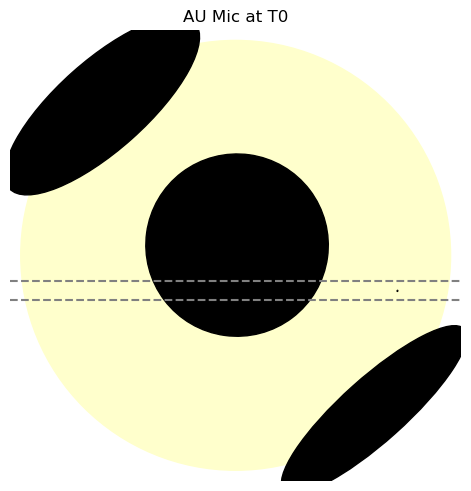

<Figure size 640x480 with 0 Axes>

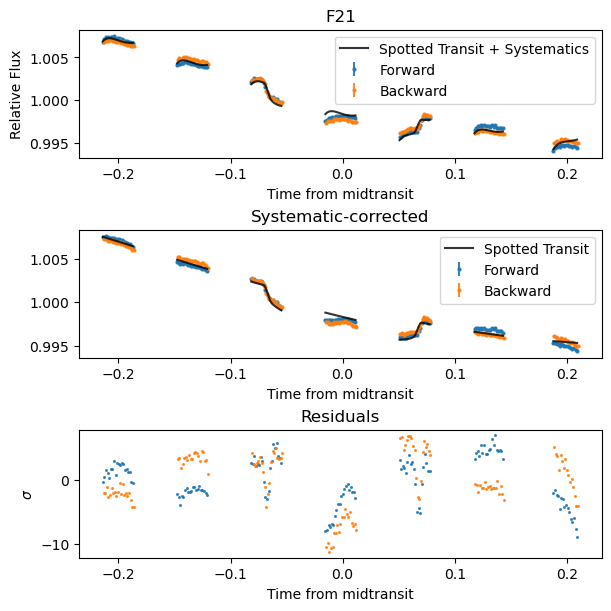

This Models Reduced Chisq = 17.536235451211734 for 25 parameters and 270 data points


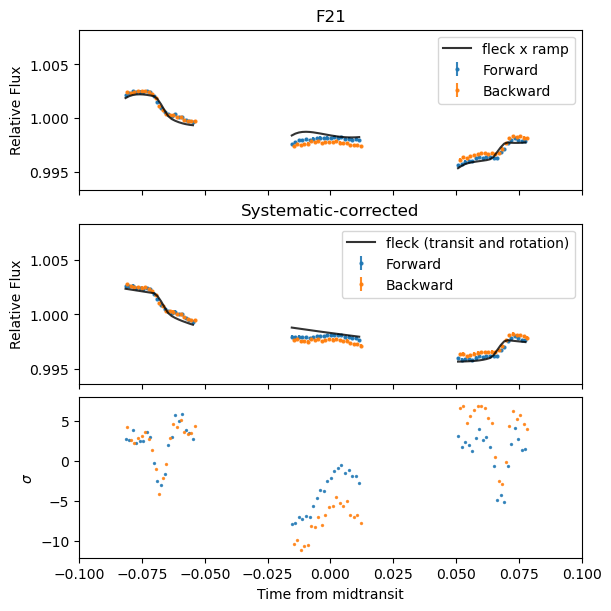

r1: 9.047488 +2.749393 -1.998148
--------------
r2: -6.107185 +0.459338 -0.262617
--------------
r3: 0.000050 +0.000427 -0.000324
--------------
b1: -0.108553 +0.050429 -0.118401
--------------
b2: 2.105642 +2.821857 -2.006954
--------------
b3: -5.199278 +29.095023 -26.835218
--------------
b4: -50.640360 +111.626584 -143.914339
--------------
phase_offset: 0.022024 +0.003331 -0.003367
--------------
u1: 0.232211 +0.059103 -0.015685
--------------
u2: 0.254510 +0.108272 -0.029703
--------------
R_0: 3.757596 +0.055666 -0.042286
--------------
a_rstar: 17.936646 +1.197727 -0.280413
--------------
ecc: 0.072331 +0.016449 -0.038535
--------------
spot1_lon: -1.110741 +0.128981 -0.043584
--------------
spot1_lat: 0.789042 +0.061629 -0.037092
--------------
spot1_rad: 0.592772 +0.009225 -0.015903
--------------
spot2_lon: 1.273658 +0.006694 -0.007539
--------------
spot2_lat: 2.412372 +0.009633 -0.007940
--------------
spot2_rad: 0.521764 +0.039008 -0.015878
--------------
spot3_lon: 0.049

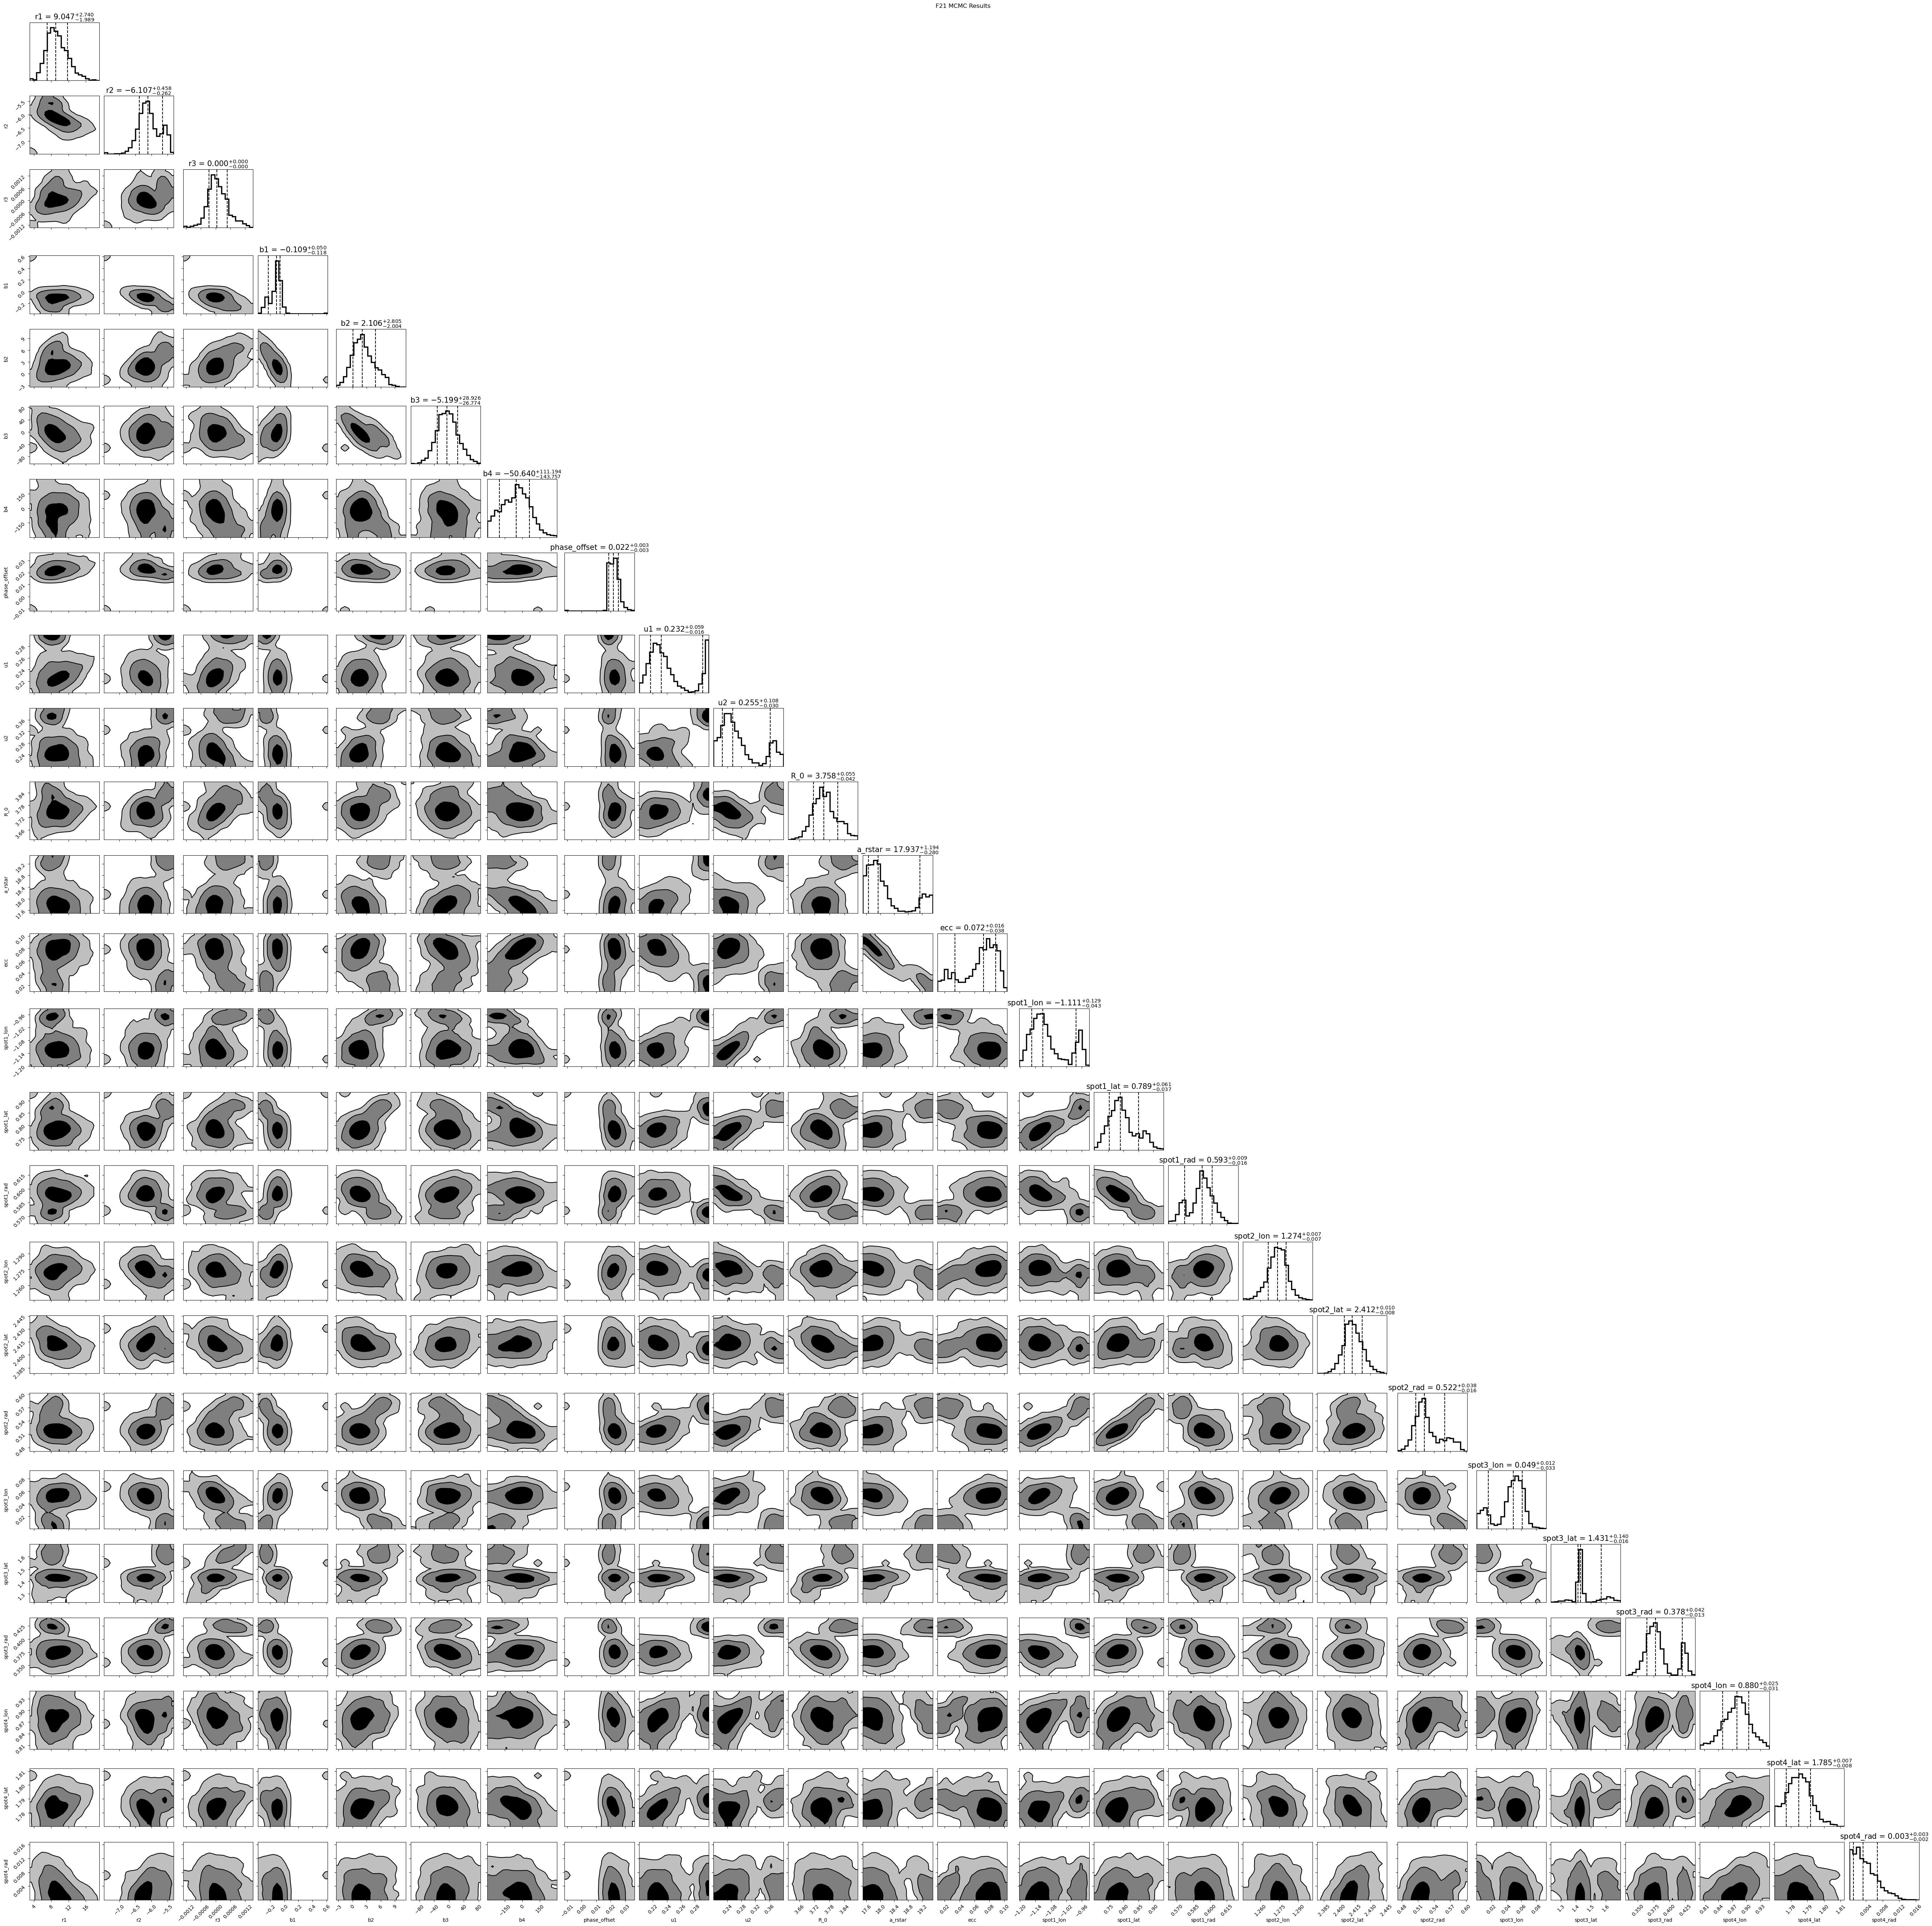

In [60]:
for visit in ['F21']:

    if visit=='F21':
        default_params = F21_default_params
        params_config = F21_params_config
        orbits_to_exclude = np.array([0])
        orbits_to_include = np.array([1,2,3,4,5,6,7])
    if visit=='S22':
        default_params = S22_default_params
        params_config = S22_params_config
        orbits_to_exclude = np.array([0,2,7])
        orbits_to_include = np.array([1,3,4,5,6])
    
    print('Running ',visit)
    print('')
        
    'Extract exposure times and mid-transit times from the dictionary'
    predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
    exposureTime = visits[f'{visit}']['exp (s)'].value
    
    'Read in the trimmed rainbows from process_pacman_spectra.ipynb'
    data_fluxes = []
    relative_errs = []
    img_dates = []
    times_from_T0 = []
    for direction in ['Forward','Reverse']:
        rainbow = read_rainbow(f"../data/{visit}_{direction}_trimmed_pacman_spec.rainbow.npy")
        broadband_flux = np.nansum(rainbow.flux.value, axis=0)
        broadband_flux_err = np.sqrt(broadband_flux)
        relative_err = err_inflation*broadband_flux_err/broadband_flux
        # print(f'Mean Photon Error for {visit} {direction} = {np.nanmean((broadband_flux_err/broadband_flux)*1e6)}ppm')
        data_fluxes.append(broadband_flux)
        relative_errs.append(relative_err)
        img_dates.append(rainbow.time.value)
        times_from_T0.append(rainbow.time.value - predicted_T0)
    
    'Label the orbits'
    orbit = np.zeros_like(img_dates[0])
    for j in range(len(img_dates[0])):
        if j >= 1:
            if (img_dates[0][j] - img_dates[0][j - 1]) > 0.01:
                orbit[j] = (orbit[j - 1] + 1)
            else:
                orbit[j] = orbit[j - 1]
    
    'Trim the first point from each orbit and the 3rd orbit from S22 (where there was a flare)'
    ref_time = []
    for o in np.unique(orbit):  # Skip the 0th orbit
        first_index = np.where(orbit == o)[0][0]
        ref_time.append(img_dates[0][first_index])
        for j in range(2):
            data_fluxes[j][first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
            relative_errs[j][first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
            img_dates[j][first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
            times_from_T0[j][first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
    
    'Trim any orbits defined in the initialization'
    for orbit_to_exclude in orbits_to_exclude:
        for j in range(2):
            data_fluxes[j][orbit == orbit_to_exclude] = np.nan
            relative_errs[j][orbit == orbit_to_exclude] = np.nan
            img_dates[j][orbit == orbit_to_exclude] = np.nan
            times_from_T0[j][orbit == orbit_to_exclude] = np.nan
    
    'Populate ramp_phase time arrays'
    ramp_phases=[0,0]
    for j in range(2):
        phase_list=[]
        for o in [0,1,2,3,4,5,6,7]:
            rphase = (img_dates[j][orbit==o] - ref_time[o]) / hst_per_in_days     # the data point at time "epoch" will be the zero-point; convert int phase by division through period
            phase_list.append(rphase)
        ramp_phases[j] = np.concatenate(phase_list)
    
    variable_names = list(params_config.keys())
    p0 = initialize_walkers(nwalkers, params_config)
    
    # Select a random set of parameters
    example_params = p0[np.random.randint(0, nwalkers - 1), :]
    
    # Call lnprob with the selected parameters and plot=True
    lnprob(example_params, plot=True)
    
    'Set up MCMC'
    label=f'{visit}_{nsteps}steps_whitelight_{n_spots}spots_model'
    samples_fname = f"../data/samples/{label}.h5"
    backend = emcee.backends.HDFBackend(samples_fname)
    backend.reset(nwalkers, ndim)        
    sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob,backend=backend)
    
    'Run the MCMC'
    print('Running MCMC sampler...')
    result = sampler.run_mcmc(p0, nsteps, store=True, progress=True)
    samples = sampler.chain[:, burnin:, :].reshape((-1, ndim)).T
    
    'Check for convergence (all should be > 100)'
    for i in range(len(samples)):
        tau_f = emcee.autocorr.integrated_time(samples[i])
        print('(Nsteps-burnin)*nwalkers/tau=',int((nsteps-burnin)*nwalkers/tau_f))
    
    'Return the Most likely set of parameters'
    flat_log_prob = sampler.get_log_prob(discard=burnin, flat=True)
    best_index = np.argmax(flat_log_prob)  # Index of the highest log-probability
    highest_prob_params = samples[:, best_index]
    print("Highest Likelihood Parameters:", highest_prob_params)
    lnprob(highest_prob_params, plot=True)
    
    'Extract and display best-fit parameters and uncertainties'
    median_params = []
    err_upper = []
    err_lower = []
    for i, param_samples in enumerate(samples):
        sig_1_results = np.percentile(param_samples, [15.9, 50.0, 84.1])
        median_params.append(sig_1_results[1])
        err_upper.append(sig_1_results[2] - sig_1_results[1])
        err_lower.append(sig_1_results[1] - sig_1_results[0])
    params_dict = {name: median_params[i] for i, name in enumerate(params_config.keys())}
    for i, label in enumerate(variable_names):
        print(f"{label}: {median_params[i]:.6f} +{err_upper[i]:.6f} -{err_lower[i]:.6f}")
        print("--------------")
    
    'Make corner plot'
    rng = 0.9995
    fig = corner.corner( 
        samples.T,show_titles=True, labels=variable_names,
        range=[rng]*ndim,smooth=1,quantiles=(0.16, 0.5, 0.84),
        fill_contours=True, plot_datapoints=False,title_kwargs={"fontsize": 15},title_fmt='.3f',
        hist_kwargs={"linewidth": 2.5},levels=[(1-np.exp(-0.5)),(1-np.exp(-2)),(1-np.exp(-4.5))])
    plt.suptitle(f"{visit} MCMC Results")
    plt.savefig(f'../figs/{visit}_{nsteps}nsteps_{n_spots}spots_corner.png',dpi=200)
    plt.show()